In [1]:
!pip install numpy scikit-learn compress-fasttext xmltodict matplotlib

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for compress-fasttext: filename=compress_fasttext-0.1.5-py3-none-any.whl size=16223 sha256=958e9936ac6f04ad57c0d8dc2064b248ea1b1c6aa5132e39d61abad268b44fbd
  Stored in directory: c:\users\sasha\appdata\local\pip\cache\wheels\18\a4\b9\4f47f495748fc70419b81cb595390cc7d04ffb6bc720f31067
Successfully built compress-fasttext

   ---------------------------------------- 2/2 [compress-fasttext]



  DEPRECATION: Building 'compress-fasttext' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'compress-fasttext'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [2]:
!pip install ruwordnet

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 4.2 MB/s eta 0:00:01
   -------------------------------- ------- 1.3/1.6 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 3.4 MB/s eta 0:00:00
  Created wheel for ruwordnet: filename=ruwordnet-0.0.6-py3-none-any.whl size=13284 sha256=1b047dc087cbc5eb6f51ac30285106fef596efdd283b0fef1855cec44261753c
  Stored in directory: c:\users\sasha\appdata\local\pip\cache\wheels\6a\de\8e\1dc45084d36f353ceada07a4202667609f185075734af19913
Successfully built ruwordnet

   ---------------------------------------- 0/3 [greenlet]
   ------------- -------------------------- 1/3 [sqlalchemy]
   ------------- -------------------------- 1/3 [sqlalchemy]
   ------------- -------------------------- 1/3 [sqlalchemy]
   ------------- -------------------------- 

  DEPRECATION: Building 'ruwordnet' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'ruwordnet'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [3]:
!ruwordnet download

downloading a ruwordnet model from https://github.com/avidale/python-ruwordnet/releases/download/0.0.4/ruwordnet-2021.db


In [4]:
from ruwordnet import RuWordNet
wn = RuWordNet()

In [5]:
!pip install razdel #для токенизации

In [19]:
import razdel
import numpy as np

In [21]:
import compress_fasttext
# библиотека для сжатия моделей fast_text
# github: https://github.com/avidale/compress-fasttext?tab=readme-ov-file
# статья на Хабре (на русском!!): https://habr.com/en/articles/489474/

from collections import Counter
from sklearn.neighbors import KDTree # библиотека для деления k-мерного пространства на отдельные фрагменты

import matplotlib.pyplot as plt
%matplotlib inline

In [22]:
# загружаем fasttext модель, которая уже была сжата заранее
ft = compress_fasttext.models.CompressedFastTextKeyedVectors.load(
    'https://github.com/avidale/compress-fasttext/releases/download/gensim-4-draft/geowac_tokens_sg_300_5_2020-100K-20K-100.bin'
)

In [9]:
# в какие синсеты входит слово "замок"? Иначе: какие значения "senses" имеет слово "замок"?
# два значения => два синсета, соответствующие этим значениям
for sense in wn.get_senses('замок'):
  print(sense.synset)

Synset(id="126228-N", title="СРЕДНЕВЕКОВЫЙ ЗАМОК")
Synset(id="114707-N", title="ЗАМОК ДЛЯ ЗАПИРАНИЯ")


In [10]:
# для первого синсета, в который входит слово "замок" получим его гиперонимы
wn.get_senses('замок')[0].synset.hypernyms

[Synset(id="113935-N", title="ДВОРЕЦ"),
 Synset(id="124420-N", title="КРЕПОСТЬ (ОБОРОНИТЕЛЬНОЕ СООРУЖЕНИЕ)")]

In [11]:
# то же самое для слова "спаржа"
wn.get_senses('спаржа')[0].synset.hypernyms

[Synset(id="348-N", title="ОВОЩИ"),
 Synset(id="4789-N", title="ТРАВЯНИСТОЕ РАСТЕНИЕ"),
 Synset(id="6878-N", title="ОВОЩНАЯ КУЛЬТУРА")]

In [12]:
wn.get_senses('авокадо') # значения слова "авокадо"

[Sense(id="144242-N-124560", name="АВОКАДО"),
 Sense(id="144305-N-124560", name="АВОКАДО"),
 Sense(id="153966-N-124560", name="АВОКАДО")]

In [13]:
# для первого значения слова "спаржа" получаем его синсет, затем находим его гиперонимы и берём первый из них
veg = wn.get_senses('спаржа')[0].synset.hypernyms[0]
veg

Synset(id="348-N", title="ОВОЩИ")

Предсказание гиперонимов

In [14]:
# в итоге получаем гипонимы овощей => согипонимы для слова "спаржа"
veg.hyponyms

[Synset(id="144194-N", title="ТЫКВА (ПЛОД)"),
 Synset(id="153883-N", title="ЗЕЛЕНЬ (ОВОЩИ)"),
 Synset(id="144191-N", title="ПОМИДОР (ПЛОД)"),
 Synset(id="144205-N", title="ПАТИССОН (ПЛОД)"),
 Synset(id="118660-N", title="ЗЕЛЕНЫЙ ГОРОШЕК"),
 Synset(id="144182-N", title="ЛУК (РАСТЕНИЕ)"),
 Synset(id="144207-N", title="СТРУЧКОВЫЙ ПЕРЕЦ (ПЛОД)"),
 Synset(id="144181-N", title="БАКЛАЖАН (ПЛОД)"),
 Synset(id="107993-N", title="АРТИШОК"),
 Synset(id="144216-N", title="КАБАЧОК (ПЛОД)"),
 Synset(id="144183-N", title="ЧЕСНОК"),
 Synset(id="108482-N", title="СПАРЖА"),
 Synset(id="144232-N", title="КОЧАН КАПУСТЫ"),
 Synset(id="148896-N", title="КОРНЕПЛОДНЫЕ ОВОЩИ"),
 Synset(id="144184-N", title="ОГУРЕЦ (ПЛОД)")]

In [24]:
# функция для векторизации текста
def vectorize(text):
    vec = np.mean([ft[word] for word in text.lower().split() if len(word) >= 3], axis=0) # вектор текста = среднее векторов слов этого текста (для слов длиннее трёх букв)
    vec /= sum(vec**2) ** 0.5 # возводим вектор vec в квадрат, складываем все чиселки этого вектора, извлекаем из этого квадратный корень и на всю эту кракозябру делим исходный вектор vec
    return vec # в итоге vec - это какое-то одно число

def distance2vote(d, a=3, b=5): # преобразование расстояние в голосование?? Не очень понятно конечно
    sim = np.maximum(0, 1 - d**2/2)
    return np.exp(-d**a) * sim **b
# то есть примерно вот что: измеряем семантическую близость векторов на основе их расстоянии в линейном пространстве

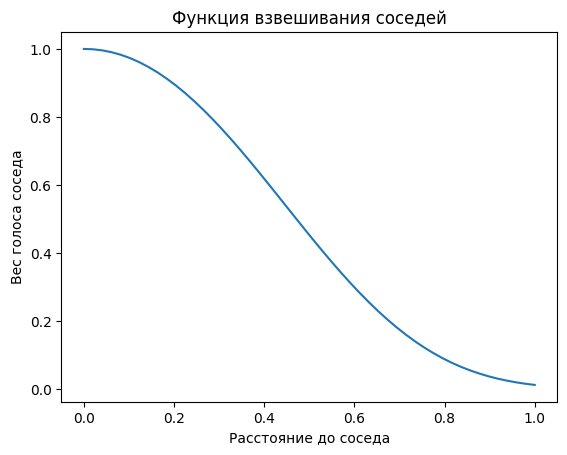

In [25]:
x = np.linspace(0, 1) # возвращает равномерно распределённые значения в пределах указанного интервала (здесь: 50 чисел, лежащих между 0 и 1, на одинаковом расстоянии друг от друга)
plt.plot(x, distance2vote(x)) # по горизонтали - расстояние между векторами, по вертикали - оценка семантической близости
plt.xlabel('Расстояние до соседа')
plt.ylabel('Вес голоса соседа')
plt.title('Функция взвешивания соседей');

In [26]:
from tqdm.auto import tqdm, trange

In [27]:
words, vectors, synset_ids = [], [], []
for synset in tqdm(wn.synsets): # в цикле перебираем все синсеты тезауруса
    if synset.part_of_speech != 'V': # если не глагол - пропускаем
        continue
    for sense in synset.senses: # для смыслов данного синсета
        words.append(sense.name) # добавляем слово
        vectors.append(vectorize(sense.name)) # добавляем вектор этого слова
        synset_ids.append(synset.id) # добавляем id синсета
vectors = np.stack(vectors) # объединяем вектора, получаем трёхмерное пространство
#tree = KDTree(vectors) # на основе этого пространства строим дерево

  0%|          | 0/59905 [00:00<?, ?it/s]

np.stack

In [29]:
tree = KDTree(vectors) # на основе этого пространства строим дерево

In [30]:
# np.stack - объединяет последовательность массивов по новой оси
# axis=0 - объединяем массивы по первой оси
# получается, что мы складываем все массивы "друг на друга", поэтому длина новой оси = 10 (исходно у нас было 10 массивов)
arrays = [np.random.randn(3, 4) for _ in range(10)] # 10 массивов размерности 3*4 (3 строки, 4 столбца)
arrays[0]
np.stack(arrays, axis=0).shape

(10, 3, 4)

In [31]:
tree = KDTree(vectors) # на основе этого пространства строим дерево

In [32]:
votes = Counter() # словарь вида значение: сколько раз значение встретилось
dists, ids = tree.query(vectorize('кудахтать').reshape(1, -1), k=100) # для слова "кудахтать" запрашиваем кусочек пространства из дерева?
for idx, distance in zip(ids[0], dists[0]):
    for hyper in wn[synset_ids[idx]].hypernyms: # получаем синсет по id и находим его гиперонимы
        votes[hyper.id] += distance2vote(distance) # для id каждого гиперонима: прибавляем значение семантической близости, предсказанное функцией distance2vote
    print(words[idx], [t.title for t in wn[synset_ids[idx]].hypernyms]) # слово, гипероним

КУДАХТАТЬ ['ИЗДАТЬ ЗВУК']
ПАХТАТЬ ['СБИТЬ В ПЛОТНУЮ МАССУ']
РАСКУДАХТАТЬСЯ ['ИЗДАТЬ ЗВУК']
КЛОХТАТЬ ['ИЗДАТЬ ЗВУК']
СБЕГАТЬ ТУДА И ОБРАТНО ['СХОДИТЬ ТУДА И ОБРАТНО']
БАРАХТАТЬСЯ ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ', 'ПЛЕСКАТЬСЯ В ВОДЕ']
СНОВАТЬ ТУДА-СЮДА ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ']
СХОДИТЬ ТУДА И ОБРАТНО ['ИДТИ НОГАМИ', 'ОБЕРНУТЬСЯ ТУДА И ОБРАТНО']
ПОДЛАТАТЬ ['ЗАШИТЬ ДЫРУ', 'НАШИТЬ СВЕРХУ']
ЗАНЫРНУТЬ ['ПОГРУЗИТЬСЯ В ЖИДКОСТЬ']
СНОВАТЬ ТУДА И ОБРАТНО ['ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ']
ПОПРЯТАТЬ ['ОБЕРЕГАТЬ, ЗАЩИЩАТЬ']
ПОПРЯТАТЬ ['НАКРЫТЬ, ПОКРЫТЬ СВЕРХУ']
СПЛАВАТЬ ТУДА И ОБРАТНО ['ПЛЫТЬ (ПЕРЕДВИГАТЬСЯ ПО ВОДЕ)', 'ПЛЫТЬ НА СУДНЕ', 'ОБЕРНУТЬСЯ ТУДА И ОБРАТНО']
РЫПАТЬСЯ ['ПЫТАТЬСЯ, СТАРАТЬСЯ', 'ХОТЕТЬ, ИМЕТЬ ЖЕЛАНИЕ']
СБЕГАТЬ И ВЕРНУТЬСЯ ['СХОДИТЬ ТУДА И ОБРАТНО']
БУРЧАТЬ ['БОРМОТАТЬ']
БУРЧАТЬ ['ИЗДАТЬ ЗВУК']
ПЕРЕБАРЫВАТЬ ['ПРЕВЗОЙТИ']
ПЕРЕБАРЫВАТЬ ['ПРЕОДОЛЕТЬ']
БРАТЬСЯ ['ПОЯВИТЬСЯ, ВОЗНИКНУТЬ, НАЧАТЬСЯ']
БРАТЬСЯ ['НАЧАТЬ, ПРИСТУПИТЬ, ПРИНЯТЬСЯ', 'ОБЯЗАТЬСЯ']
БРАТЬСЯ ['БРАТЬ РУКОЙ, ЗУБАМИ, ОРУДИЕМ']
БРАТЬСЯ ['П

In [33]:
# напечатаем 10 наиболее семантически близких к данному слову гиперонимов
for sid, score in votes.most_common(10):
    print(score,  wn[sid].title)

1.693910435463562 ИЗДАТЬ ЗВУК
0.4132547441687813 ДВИЖЕНИЕ, ПЕРЕМЕЩЕНИЕ
0.3097076148668363 СБИТЬ В ПЛОТНУЮ МАССУ
0.25169095401266095 СПУСТИТЬСЯ ВНИЗ
0.22120903181668677 СХОДИТЬ ТУДА И ОБРАТНО
0.20195221302283534 ОБЕРНУТЬСЯ ТУДА И ОБРАТНО
0.1896130809969685 ЗАШИТЬ ДЫРУ
0.1896130809969685 НАШИТЬ СВЕРХУ
0.18951210591007633 ИДТИ НОГАМИ
0.1778837765054719 КАЧАТЬ (КОЛЕБАТЬ)


Поиск лишнего

In [34]:
import math


def get_all_hypernyms(wn, word, max_level=100):
    """ Return dict of all hypernyms of a word and their distances """
    """Возвращает все гиперонимы слова word и их расстояния"""
    front = [sense.synset for sense in wn.get_senses(word)] # список синсетов всех значений слова "word"
    levels = {}
    for level in range(max_level):
        if not front: # если список синсетов пуст - прерываем, иначе - продолжаем
            break
        new_front = []
        for synset in front:
            if synset.id not in levels:
                levels[synset.id] = level # добавляем в словарь пару id синсета: уровень (непонятно, что за уровень, но у каждого синсета он будет самый ранний встреченный)
                new_front.extend(synset.hypernyms) # добавляем в список new_front гиперонимы
        front = new_front
    return levels

def get_closest_common(levels1, levels2): # на вход - гиперонимы + расстояния для Слова 1 и гиперонимы + расстояния для Слова 2
    """ Find the closest common hypernym and sum of distances to it"""
    """Возвращает самый близкий гипероним и суммирует расстояния до него"""
    result = None
    result_distance = math.inf # положительная бесконечность, тип - float
    for id, distance in levels1.items():
        if id in levels2:
            total = distance + levels2[id]
            if total < result_distance: # чем меньше значение distance - тем семантически ближе данный гипероним
                result_distance = total # обнавляем значение расстояния
                result = id # и значение id самого подходящего синсета-гиперонима
    return result, result_distance

In [35]:
# получим таблицу с расстояниями между соотв. словами? (вроде бы...)
words = ['ДИВАН', 'ШКАФ', 'ЛАМПА', 'СТОЛ']
print('\t\t', '\t'.join(words))
for w1 in words:
    print(w1, end='\t')
    for w2 in words:
        n, d = get_closest_common(get_all_hypernyms(wn, w1), get_all_hypernyms(wn, w2))
        print(d, end='\t\t')
    print()

		 ДИВАН	ШКАФ	ЛАМПА	СТОЛ
ДИВАН	0		3		10		3		
ШКАФ	3		0		5		2		
ЛАМПА	10		5		0		7		
СТОЛ	3		2		7		0		


In [36]:
# видимо, наиболее близкий общий гипероним! id синсета и название этого синсета
name, distance = get_closest_common(get_all_hypernyms(wn, 'лампа'), get_all_hypernyms(wn, 'шкаф'))
print(distance, name, wn[name].title)

5 106555-N ТЕХНИЧЕСКОЕ УСТРОЙСТВО


In [37]:
# гиперонимы слова "лампа": id гиперонима, расстояние до слова "лампа", сам синсет гиперонима
for k, v in get_all_hypernyms(wn, 'лампа').items():
    print(k, v, wn[k])

128561-N 0 Synset(id="128561-N", title="ОСВЕТИТЕЛЬНЫЙ ПРИБОР")
8785-N 0 Synset(id="8785-N", title="ЭЛЕКТРИЧЕСКАЯ ЛАМПА")
107646-N 1 Synset(id="107646-N", title="ИСТОЧНИК ОСВЕЩЕНИЯ")
4222-N 1 Synset(id="4222-N", title="СВЕТОТЕХНИЧЕСКОЕ ОБОРУДОВАНИЕ")
106488-N 2 Synset(id="106488-N", title="ИСХОДНЫЙ ПУНКТ")
2070-N 2 Synset(id="2070-N", title="ЭЛЕКТРОТЕХНИЧЕСКОЕ ОБОРУДОВАНИЕ")
106613-N 3 Synset(id="106613-N", title="РОЛЬ, ПОЛОЖЕНИЕ, МЕСТО")
149201-N 3 Synset(id="149201-N", title="ИНЖЕНЕРНОЕ ОБОРУДОВАНИЕ")
106555-N 4 Synset(id="106555-N", title="ТЕХНИЧЕСКОЕ УСТРОЙСТВО")
1320-N 4 Synset(id="1320-N", title="ОБОРУДОВАНИЕ")
106553-N 5 Synset(id="106553-N", title="ПРИСПОСОБЛЕНИЕ (ПРЕДМЕТ)")
106554-N 6 Synset(id="106554-N", title="ПРЕДМЕТ, ВЕЩЬ")
147133-N 7 Synset(id="147133-N", title="ФИЗИЧЕСКИЙ ОБЪЕКТ")
147134-N 8 Synset(id="147134-N", title="ФИЗИЧЕСКАЯ СУЩНОСТЬ")
153782-N 9 Synset(id="153782-N", title="ПОСТОЯННАЯ СУЩНОСТЬ")


### Word Sense Disambiguation (WSD)

In [38]:
def disambiguate(word, context):
    candidates = [s.synset for s in wn[word]] # кандидаты для разрешения семантической неоднозначности - значения целевого слова word
    text_vector = vectorize(' '.join(t.text for t in razdel.tokenize(context) if t.text != word)) # векторизуем текст; перед этим его токенизируем с помощью razdel; целевое слово не учитываем!
    candidate_vectors = [ # получим вектора значений-кандидатов
        vectorize(' '.join(w for s in c.senses for w in s.name.lower().split() if name != word))
        for c in candidates # перебираем кандидатов
    ]
    # запуталась в циклах, но по сути: для каждого кандидата (это синсет) берём его senses, достаём их названия, соединяем через пробел и всё это векторизуем, при этом целевое слово опять не учитываем
    scores = [np.dot(text_vector, v) for v in candidate_vectors] # оценка = скалярное произведение вектора-текста и вектора-кандидата
    # чем выше эта оценка, тем вероятнее неоднозначное слово употреблено в данном значении

    return dict(zip(scores, candidates))

Давайте попробуем разобрать слово "площадь"

In [39]:
word = 'площадь'
context1 = 'Площадь - это геометрическое понятие, обозначающее величину, характеризующую размер плоской фигуры или поверхности.' # Математика
context2 = 'открытое пространство в городе, обрамленное зданиями или зеленью, часто играющее важную градостроительную роль.' # Город

In [40]:
scores1 = disambiguate(word, context1)
max_score = max(scores1.keys())
print(f'Значение в данном контексте: {scores1[max_score]} - {max_score}')

Значение в данном контексте: Synset(id="107315-N", title="ПЛОЩАДЬ (ПАРАМЕТР)") - 0.620424423889535


In [41]:
scores2 = disambiguate(word, context2)
max_score = max(scores2.keys())
print(f'Значение в данном контексте: {scores2[max_score]} - {max_score}')

Значение в данном контексте: Synset(id="114034-N", title="ПЛОЩАДЬ В ГОРОДЕ, СЕЛЕ") - 0.5302577388726782
